# Import libraries

Add directory with CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and some other packages

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form. In the future a separate class will likely be constructed to handle this.

In [4]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})
x0_ani_raw = x0_ani.copy()

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='slaktkycklingar','poultry',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='hästar','horses',x0_ani['species'])

# Add horse breeds
x0_ani = pd.concat([
    x0_ani[x0_ani.animal != 'hästar'],
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'ponnyer'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'kallblod'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'ridhästar'}),
    x0_ani[x0_ani.animal == 'hästar'].replace({'hästar':'trav och galopp'})
    ])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='slaktkycklingar','broiler',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='ponnyer','ponies and Icelandic horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kallblod','cold blooded horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='ridhästar','riding horses',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='trav och galopp','trotters and racehorses',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

# Numbers per horse breed
x0_ani.update(x0_ani.xs(('horses','ponies and Icelandic horses'),level=('species','breed'),drop_level=False) * 0.297)  
x0_ani.update(x0_ani.xs(('horses','cold blooded horses'),level=('species','breed'),drop_level=False) * 0.100)  
x0_ani.update(x0_ani.xs(('horses','riding horses'),level=('species','breed'),drop_level=False) * 0.343)  
x0_ani.update(x0_ani.xs(('horses','trotters and racehorses'),level=('species','breed'),drop_level=False) * 0.260)  

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

# Run test scenario 'baseline'
This test scenario includes ...
1. A 0.6% year-on-year increase in population (parameter='population'),
1. a 6% increase in milk yield per cow  per every 5 years (parameter='milk_prod'),
2. an overall yield increase of 5% from 2020 to 2050 for all crops (parameter='yield'),
3. a 1% year-on-year decrease in pig meat consumption up until 2040 (parameter='consumption').

The scenario is defined in the different parameter Excel files in 'data/production_parameters' under the sheets named 'scn_baseline'

Note: Warnings are printed as the scenario is not defined in all parameter Excel files.

## Run model

Select which scenario to use, years to calculate output for and create a container to store output per year.

In [5]:
# Define scenario, years and create output container
scn = 'baseline'
years = ['2020','2030','2040','2050']
output = pd.DataFrame(
    columns=['crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':scn,'year':years}))
)

Instantiate modules (classes). Each module is intialised with a **ParameterRetriever** object which reads a supplied parameter Excel-file and handles the retrieval of parameter values used in the calculations. The **ParameterRetriever** also handles updating parameter values according to a scenario.

There are three main modules that stores data as attributes (generaly in the form of pandas.DataFrames). These are:

**DemandAndConversions:**
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

**CropProduction:**
This module calculates production of crop products per unit (area) of crop in a certain region.

**AnimalHerd:**
This module has subclasses for each animal species and is initialised as one AnimalHerd object per species,breed,production system combination. This module calculates production of animal products per animal unit (i.e. the defining animal). Defining animal differs accros production systems with e.g. 'cows' for **CattleHerd**s, 'sows+gilts' for **PigHerd**s and 'total horses' for **HorseHerd**s.

The there are a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

**FeedMgmt:**
Desc.

**ManureMgmt:**
Desc.

**FertiliserMgmt:**
Desc.

Finaly the module **GeoDistributor** handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [6]:
# Instantiate diet class
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','DemandAndConversions.xlsx')
    )
)

# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','CropProduction.xlsx')),
    index = x0_crp.index
)    

# Instantiate animal herds
# Each animal herd object is stored in an indexed pandas.Series
# A function will be developed to handle this in a more user-friendly way
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        for ss in ['maize based','none'] if (ps == 'conventional') else ['none']:
            herds[(sp,br,ps,ss)] = \
                cm.CattleHerd(
                    par = cm.ParameterRetriever(
                        os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                    ),
                    index = x0_ani.index.get_level_values('region').unique(),
                    breed = br,
                    prod_system = ps,
                    sub_system = ss
                )
    elif sp == 'horses':
        herds[(sp,br,ps,'none')] = \
            cm.HorseHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','HorseHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )
    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','PigHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )
    elif sp == 'poultry':
        if br == 'broiler':
            herds[(sp,br,ps,'none')] = \
            cm.BroilerHerd(
                par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','BroilerHerd.xlsx')),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FeedMgmt.xlsx'))
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','ManureMgmt.xlsx'))
)

# Instantiate fertiliser management
fertiliser_mgmt = cm.FertiliserMgmt(
    crops = crops,
    herds = herds,
    demand = demand,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FertiliserMgmt.xlsx'))
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    x0 = x0,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever(os.path.join('..','data','prod_parameters','FertiliserMgmt.xlsx'))
)

Now we have initialised all modules and can do the calculations. This is done by looping through the years and first updating all parameter values according to the speciefied scenario and year the (re-)calculating all classes and running the **GeoDistributor** to distribute crops and animals across regions. Finally the ouputs are stored.

In [9]:
# Loop through years
for year in years:
    print(year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(scn,year)
    
    # Calculate food demand
    demand.calculate(verbose=True)

    # Calculate crops
    crops.calculate(
        verbose = True
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose = True)

    # Calculate feed
    feed_mgmt.calculate(verbose=True)    

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6], scale_power=[0.25,0], verbose=True)
    # Solve optimisation problem
    geodist.solve(
        verbose=True,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':1e-6,
            'eps_rel':1e-6,
            'verbose':False
        }
    )
    
    # Scale results
    crops.scale(geodist.x['crp'])
    for h in herds:
        h.scale(
            geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
            x_is = h.x_is
        )
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate fertiliser
    fertiliser_mgmt.calculate(verbose=True)
    
    # Store results
    # Crops
    output.loc[(scn,year),'crp'] = \
    crops.make_static()
    # Animals
    output.loc[(scn,year),'ani'] = \
    concat_herds(
        herds.apply(lambda x: x.make_static())
    )

2020


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FertiliserMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\r

[11:53:55][Diet] Calculating food demand ...
[11:53:55][Diet] Calculating waste ...
[11:53:55][Diet] Calculating crop product demand ...
[11:53:55][Diet] Calculating crop product demand ...
[11:53:56][Diet] Done! Elapsed time: 1 sec
[11:53:56][CropProduction] Calculating harvest ...
[11:53:56][CropProduction] Calculating production ...
[11:53:59][CropProduction] Calculating seed demand ...
[11:54:00][CropProduction] Done! Elapsed time: 5 sec
[11:54:00][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:54:01][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:54:01][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:54:01][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:54:01][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:54:01][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:54:01][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


[11:55:33][FertiliserMgmt] Distributing manure ...
[11:55:33][FertiliserMgmt] Done! Elapsed time: 2 sec


...

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FertiliserMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\HorseHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\r

[11:58:37][Diet] Calculating food demand ...
[11:58:37][Diet] Calculating waste ...
[11:58:37][Diet] Calculating crop product demand ...
[11:58:37][Diet] Calculating crop product demand ...
[11:58:37][Diet] Done! Elapsed time: 1 sec
[11:58:37][CropProduction] Calculating harvest ...
[11:58:37][CropProduction] Calculating production ...
[11:58:41][CropProduction] Calculating seed demand ...
[11:58:42][CropProduction] Done! Elapsed time: 5 sec
[11:58:42][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:58:42][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:58:42][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:58:42][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:58:43][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:58:43][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:58:43][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


[12:00:04][FertiliserMgmt] Distributing manure ...
[12:00:04][FertiliserMgmt] Done! Elapsed time: 2 sec


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\output_data_manip.py:36: UserWarning: Data attributes {'feed.energy_req'} not pressent in all AnimalHerds and therfore not retained.
  warnings.warn(f'Data attributes {data_attr_in_some} not pressent in all AnimalHerds and therfore not retained.')


## Plot output

In [18]:
np.ceil(len(idxs)/4)

2.0

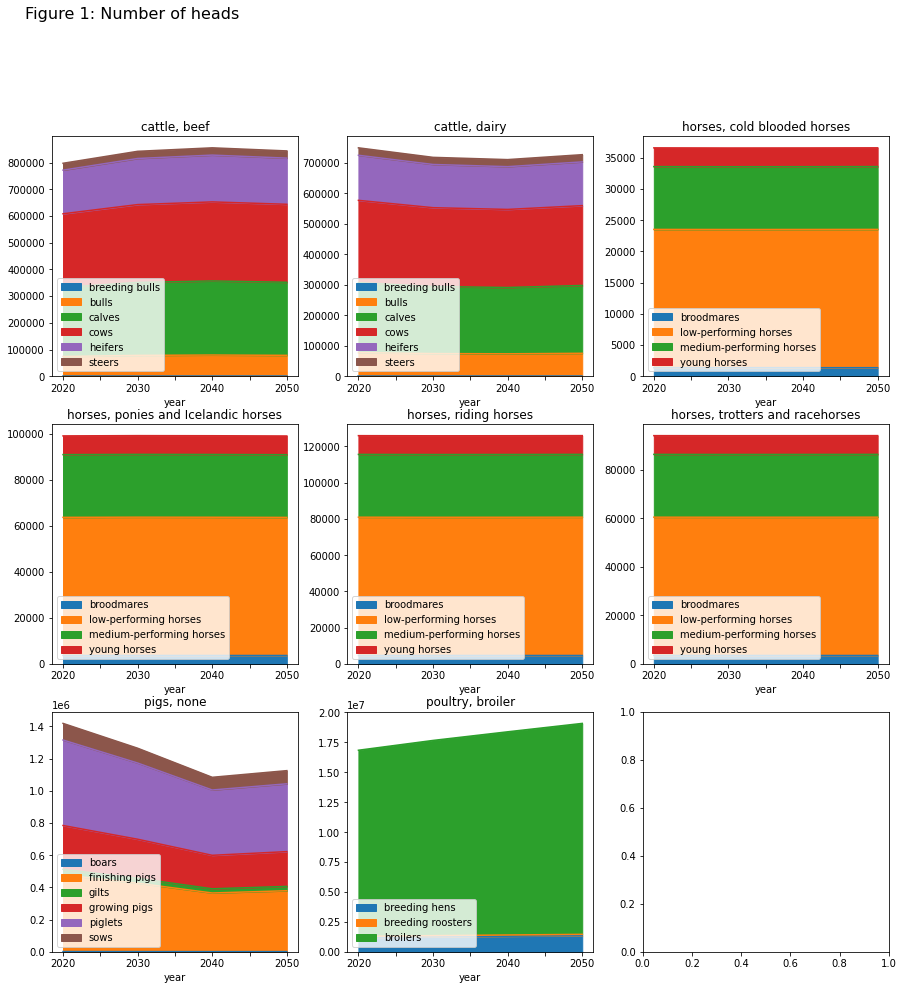

In [29]:
## FIGURE 1 --------------------->

# Number of animal heads
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].heads.groupby(['species','breed','animal'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

idxs = plot_data.columns.droplevel('animal').unique()

rows = 3
cols = int(np.ceil(len(idxs)/rows))
fig, axs = plt.subplots(rows,cols, figsize=(5*cols,5*rows))

r = 0
c = 0

for idx in idxs:
    
    ax=axs[r,c]
    
    (
        plot_data.xs(idx,level=['species','breed'],axis=1).
        reset_index().plot.area(x='year', ax = ax, stacked=True)
    )
    
    ax.set_title(', '.join(idx),color='black')
    ax.legend(loc='lower left')
    if c == cols-1:
        c = 0
        r += 1
    else:
        c += 1
        
plt.suptitle('Figure 1: Number of heads', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()

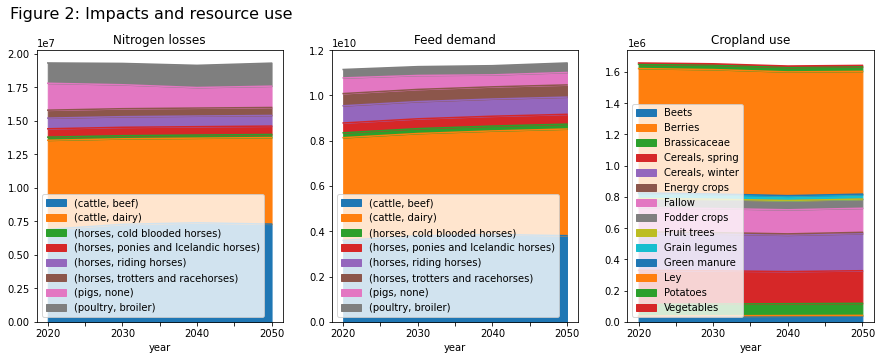

In [32]:
## FIGURE 2 --------------------->
# N losses

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].manure.N_loss.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

fig, axs = plt.subplots(1,3, figsize=(15,5))

(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[0], stacked=True)
)

axs[0].legend(loc='lower left')   
axs[0].set_title('Nitrogen losses')

# Feed demand

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].feed.crop_product_demand.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[1], stacked=True)
)

axs[1].legend(loc='lower left')
axs[1].set_title('Feed demand')

# Cropland use

# crop --> crop_group
cg_rel = pd.Series(crops.par.get_rel('crop','crop_group')).rename('crop_group').rename_axis('crop')
# crop --> land_use
lu_rel = pd.Series(crops.par.get_rel('crop','land_use')).rename('land_use').rename_axis('crop')

idx = pd.IndexSlice

plot_data = pd.concat([
    (
        output.loc[(scn,y),'crp'].area.rename('area')
        .to_frame().join(cg_rel).join(lu_rel)
        .set_index('land_use', append=True)
        .loc[idx[:,:,:,'cropland']]
        .groupby('crop_group').sum()['area']
    )
    for y in years
], axis=1).T
plot_data.index = pd.Index(years,name='year')
(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[2], stacked=True)
)

axs[2].legend(loc='lower left')
axs[2].set_title('Cropland use')

plt.suptitle('Figure 2: Impacts and resource use', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()